### 🗂️ Projects Covered
| # | Project | Target Variable | Task |
|---|---------|----------------|------|
| 1 | **Loan Default Dataset** | `person_income` (regression) & `loan_status` (classification) | Predict income + loan repayment |
| 2 | **Salary Dataset** | `salary_in_usd` (regression) & salary bucket (classification) | Predict salaries in tech jobs |


###  CRISP-DM Framework
```
Business Understanding -> Data Understanding -> Data Preparation 
     -> Modeling -> Evaluation -> Deployment

##  Phase 0: Environment Setup

Before we even look at the data, let's load our toolkit. Think of this as a chef preparing their mise en place -- everything in its place before cooking begins.
 
Every library below serves a distinct purpose:
- **pandas / numpy** -- our data wrangling workhorses
- **matplotlib / seaborn** -- our storytelling canvas
- **scipy / statsmodels** -- for statistical tests and regression diagnostics
- **sklearn** -- our machine learning engine


In [36]:
# --- Core Libraries --------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
# --- Statistics -------------------------------------------------------------
from scipy import stats
from scipy.stats import shapiro, jarque_bera, levene, boxcox
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
 
# --- Preprocessing ----------------------------------------------------------
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder, StandardScaler,
                                    MinMaxScaler, PowerTransformer)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
 
# --- Regression Models ------------------------------------------------------
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   LogisticRegression)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVR
 
# --- Metrics ----------------------------------------------------------------
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              ConfusionMatrixDisplay)
 
# --- Styling ----------------------------------------------------------------
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")
pd.set_option('display.float_format', '{:.4f}'.format)

print("OK: All libraries loaded successfully!")

OK: All libraries loaded successfully!


**Findings:** The environment setup completed successfully, so the notebook has the libraries needed for data cleaning, visualization, diagnostics, and machine learning. This step confirms the analysis can proceed without import-related blockers.


# 🏦 PROJECT 1: Loan Default & Income Prediction
 
---
 
## 📖 Phase 1: Business Understanding
 
### The Story
 
Imagine you work as a data scientist at a lending institution -- say, QuickFin Bank. The bank processes thousands of loan applications every month and faces two expensive problems:
 
1. **Problem A (Regression):** Applicants sometimes misreport their income. Can we *predict* what someone's income should be, based on their profile? This helps in fraud detection and income verification.
 
2. **Problem B (Classification):** Even with verified income, some borrowers default. Can we *predict who will default* before we approve the loan? This directly impacts profitability and risk exposure.
 
### Business Questions
- What demographic and financial factors drive income?
- Which borrowers are most likely to default on their loans?
- How does credit score interact with loan defaults?
 
### Success Criteria
- Regression model: R² > 0.60 on test set
- Classification model: AUC-ROC > 0.75

## 📋 Phase 2: Data Understanding
 
Let's meet our dataset. Just like meeting a new colleague -- first impressions matter, but we need to dig deeper.

In [37]:
# --- Load the Loan Dataset --------------------------------------------------
loan_df = pd.read_csv('loan_data.csv')
 
print(f"📐 Shape: {loan_df.shape[0]:,} rows x {loan_df.shape[1]} columns")
print()
print("📑 Columns:")
for col in loan_df.columns:
    print(f"   - {col} ({loan_df[col].dtype})")

📐 Shape: 45,000 rows x 14 columns

📑 Columns:
   - person_age (float64)
   - person_gender (object)
   - person_education (object)
   - person_income (float64)
   - person_emp_exp (int64)
   - person_home_ownership (object)
   - loan_amnt (float64)
   - loan_intent (object)
   - loan_int_rate (float64)
   - loan_percent_income (float64)
   - cb_person_cred_hist_length (float64)
   - credit_score (int64)
   - previous_loan_defaults_on_file (object)
   - loan_status (int64)


**Findings:** The dataset loads with 45,000 rows and 14 columns, giving us a fairly large sample for both regression and classification. The column types show a mix of numeric and categorical variables, which means we will need both statistical analysis and encoding before modeling.


In [38]:
# --- First Peek -------------------------------------------------------------
print("First 5 rows:")
loan_df.head()

First 5 rows:


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0000,female,Master,71948.0000,0,RENT,35000.0000,PERSONAL,16.0200,0.4900,3.0000,561,No,1
1,21.0000,female,High School,12282.0000,0,OWN,1000.0000,EDUCATION,11.1400,0.0800,2.0000,504,Yes,0
2,25.0000,female,High School,12438.0000,3,MORTGAGE,5500.0000,MEDICAL,12.8700,0.4400,3.0000,635,No,1
3,23.0000,female,Bachelor,79753.0000,0,RENT,35000.0000,MEDICAL,15.2300,0.4400,2.0000,675,No,1
4,24.0000,male,Master,66135.0000,1,RENT,35000.0000,MEDICAL,14.2700,0.5300,4.0000,586,No,1


**Findings:** The first few rows help verify that the dataset structure matches our expectations and that the values look realistic at a glance. This quick inspection is useful for catching obvious issues such as misaligned columns, wrong delimiters, or unexpected text formats.


In [39]:
# --- Statistical Summary ----------------------------------------------------
print("📊 Descriptive Statistics (Numerical Columns):")
loan_df.describe().T.style.background_gradient(cmap='Blues')

📊 Descriptive Statistics (Numerical Columns):


,count,mean,std,min,25%,50%,75%,max
person_age,45000.000000,27.764178,6.045108,20.000000,24.000000,26.000000,30.000000,144.000000
person_income,45000.000000,80319.053222,80422.498632,8000.000000,47204.000000,67048.000000,95789.250000,7200766.000000
person_emp_exp,45000.000000,5.410333,6.063532,0.000000,1.000000,4.000000,8.000000,125.000000
loan_amnt,45000.000000,9583.157556,6314.886691,500.000000,5000.000000,8000.000000,12237.250000,35000.000000
loan_int_rate,45000.000000,11.006606,2.978808,5.420000,8.590000,11.010000,12.990000,20.000000
loan_percent_income,45000.000000,0.139725,0.087212,0.000000,0.070000,0.120000,0.190000,0.660000
cb_person_cred_hist_length,45000.000000,5.867489,3.879702,2.000000,3.000000,4.000000,8.000000,30.000000
credit_score,45000.000000,632.608756,50.435865,390.000000,601.000000,640.000000,670.000000,850.000000
loan_status,45000.000000,0.222222,0.415744,0.000000,0.000000,0.000000,0.000000,1.000000


**Findings:** The descriptive statistics summarize the scale and spread of the numeric variables. In particular, the wide range in `person_income` suggests strong variability and hints that outliers or skewness may influence downstream modeling if left untreated.


In [40]:
# --- Missing Values Audit ---------------------------------------------------
missing = loan_df.isnull().sum()
missing_pct = (missing / len(loan_df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values Report:")
print(missing_report[missing_report['Missing Count'] > 0])
print("OK: No missing values!" if missing.sum() == 0 else "WARNING: Missing values found!")

Missing Values Report:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
OK: No missing values!


**Findings:** The missing-value audit shows that the loan dataset is complete, so no imputation is required at this stage. That simplifies preprocessing and lets us focus on outliers, feature engineering, and encoding.


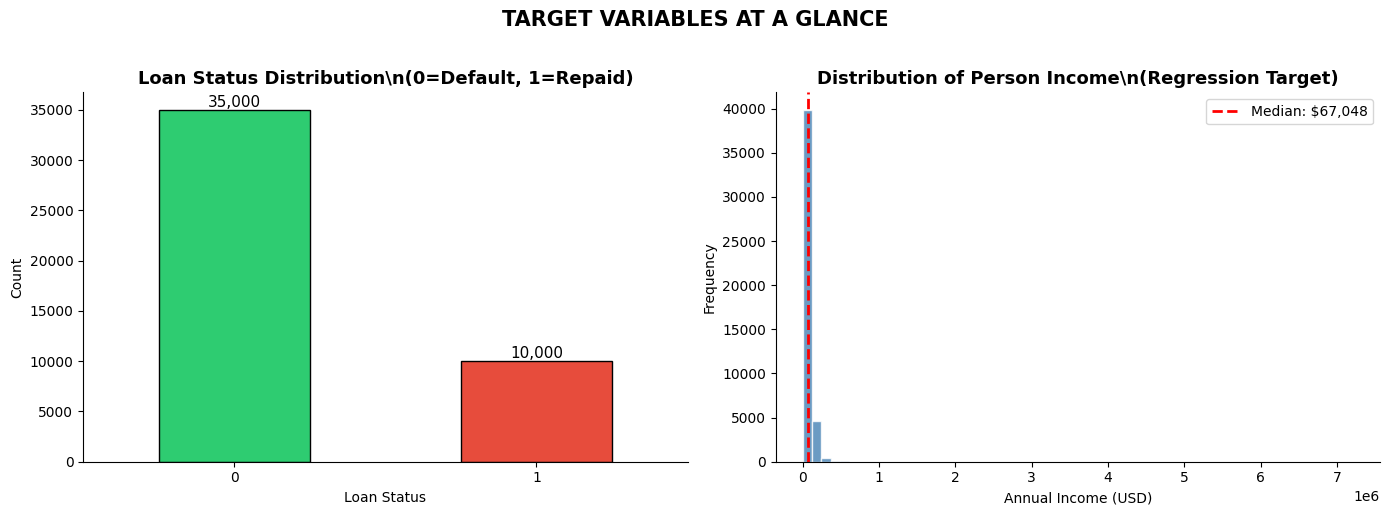

NOTE: Class Balance:
loan_status
Default   0.7778
Repaid    0.2222
NOTE: Income Stats:
   Mean:   $   80,319.05
   Median: $   67,048.00
   Std:    $   80,422.50


In [41]:
# --- Target Variable Distribution -----------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Loan Status (classification target)
loan_df['loan_status'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'],
                                            edgecolor='black', rot=0)
axes[0].set_title('Loan Status Distribution\\n(0=Default, 1=Repaid)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width()/2., bar.get_height()),
                     ha='center', va='bottom', fontsize=11)
 
# Income (regression target)
axes[1].hist(loan_df['person_income'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Person Income\\n(Regression Target)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Annual Income (USD)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(loan_df['person_income'].median(), color='red', linestyle='--', linewidth=2, label=f"Median: ${loan_df['person_income'].median():,.0f}")
axes[1].legend()
 
plt.suptitle('TARGET VARIABLES AT A GLANCE', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"NOTE: Class Balance:")
print(loan_df['loan_status'].value_counts(normalize=True).rename({0:'Default',1:'Repaid'}).to_string())
print(f"NOTE: Income Stats:")
print(f"   Mean:   ${loan_df['person_income'].mean():>12,.2f}")
print(f"   Median: ${loan_df['person_income'].median():>12,.2f}")
print(f"   Std:    ${loan_df['person_income'].std():>12,.2f}")
 

**Findings:** The target plots show two important patterns. First, `person_income` is strongly right-skewed, which is why a transformation is later considered. Second, the `loan_status` classes are imbalanced, so evaluation metrics such as AUC-ROC are more informative than accuracy alone.


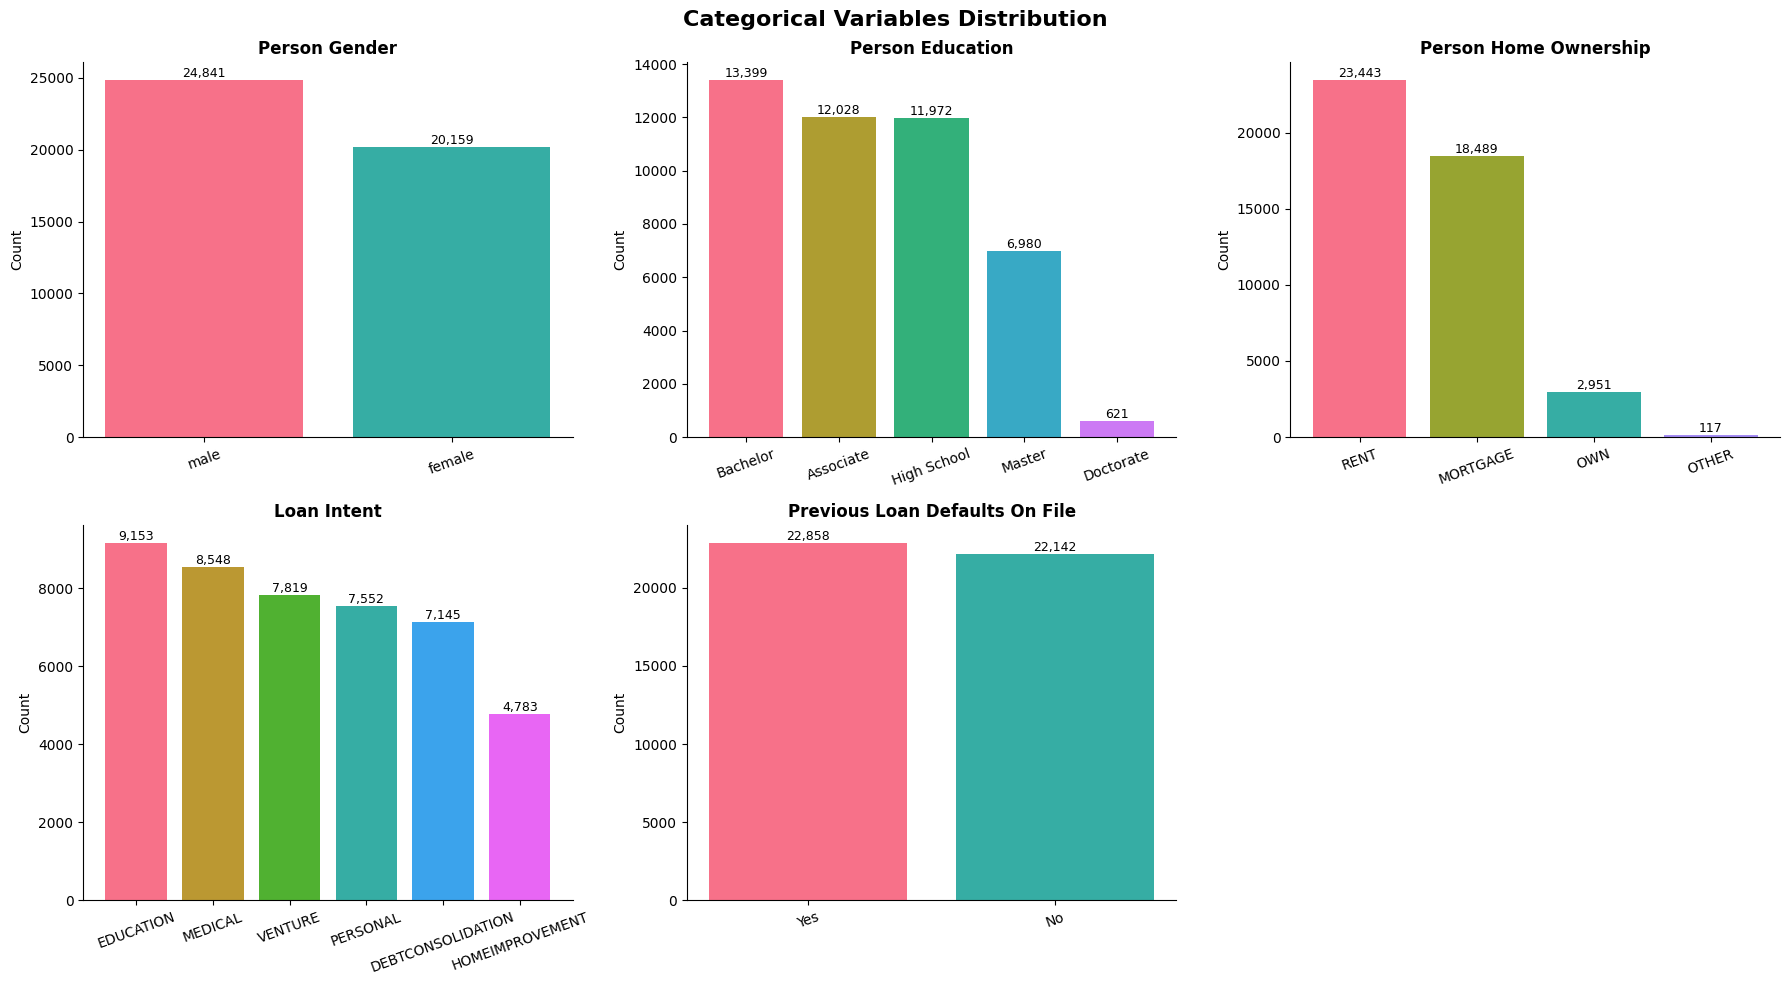

In [42]:
# --- Categorical Variables Exploration ------------------------------------
cat_cols = ['person_gender','person_education','person_home_ownership',
            'loan_intent','previous_loan_defaults_on_file']
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
 
for i, col in enumerate(cat_cols):
    counts = loan_df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values, color=sns.color_palette("husl", len(counts)))
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=20)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                     f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
 
axes[5].axis('off')  # hide last empty subplot
plt.suptitle('Categorical Variables Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:** The categorical distributions give us a sense of the borrower mix in the dataset. These patterns matter because uneven category counts can affect model behavior and may also reveal which borrower groups dominate the training data.


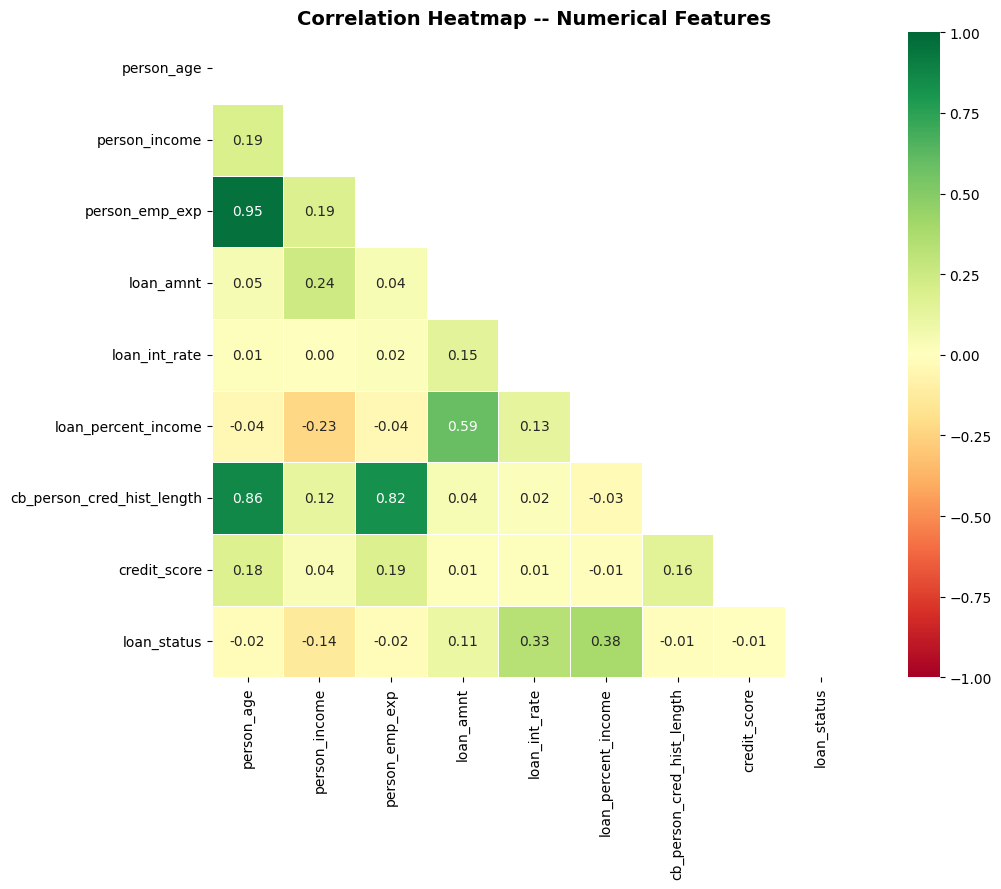

NOTE: Correlations with person_income:
person_income                 1.0000
loan_amnt                     0.2423
person_age                    0.1937
person_emp_exp                0.1860
cb_person_cred_hist_length    0.1243
credit_score                  0.0359
loan_int_rate                 0.0015
loan_status                  -0.1358
loan_percent_income          -0.2342


In [43]:
# --- Numerical Correlations Heatmap ----------------------------------------
num_cols = loan_df.select_dtypes(include=np.number).columns.tolist()
corr_matrix = loan_df[num_cols].corr()
 
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap -- Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Highlight strong correlations with income
print("NOTE: Correlations with person_income:")
print(corr_matrix['person_income'].sort_values(ascending=False).to_string())

**Findings:** The correlation heatmap highlights how the numeric variables move together. It is especially useful for spotting potentially predictive variables for income and for identifying collinearity risks that may weaken linear-model interpretation.


 Outlier Audit (IQR method):
   person_age                              : 2,188 outliers (4.9%)
   person_income                           : 2,218 outliers (4.9%)
   person_emp_exp                          : 1,724 outliers (3.8%)
   loan_amnt                               : 2,348 outliers (5.2%)
   loan_int_rate                           :   124 outliers (0.3%)
   loan_percent_income                     :   744 outliers (1.7%)
   cb_person_cred_hist_length              : 1,366 outliers (3.0%)
   credit_score                            :   467 outliers (1.0%)
   loan_status                             : 10,000 outliers (22.2%)


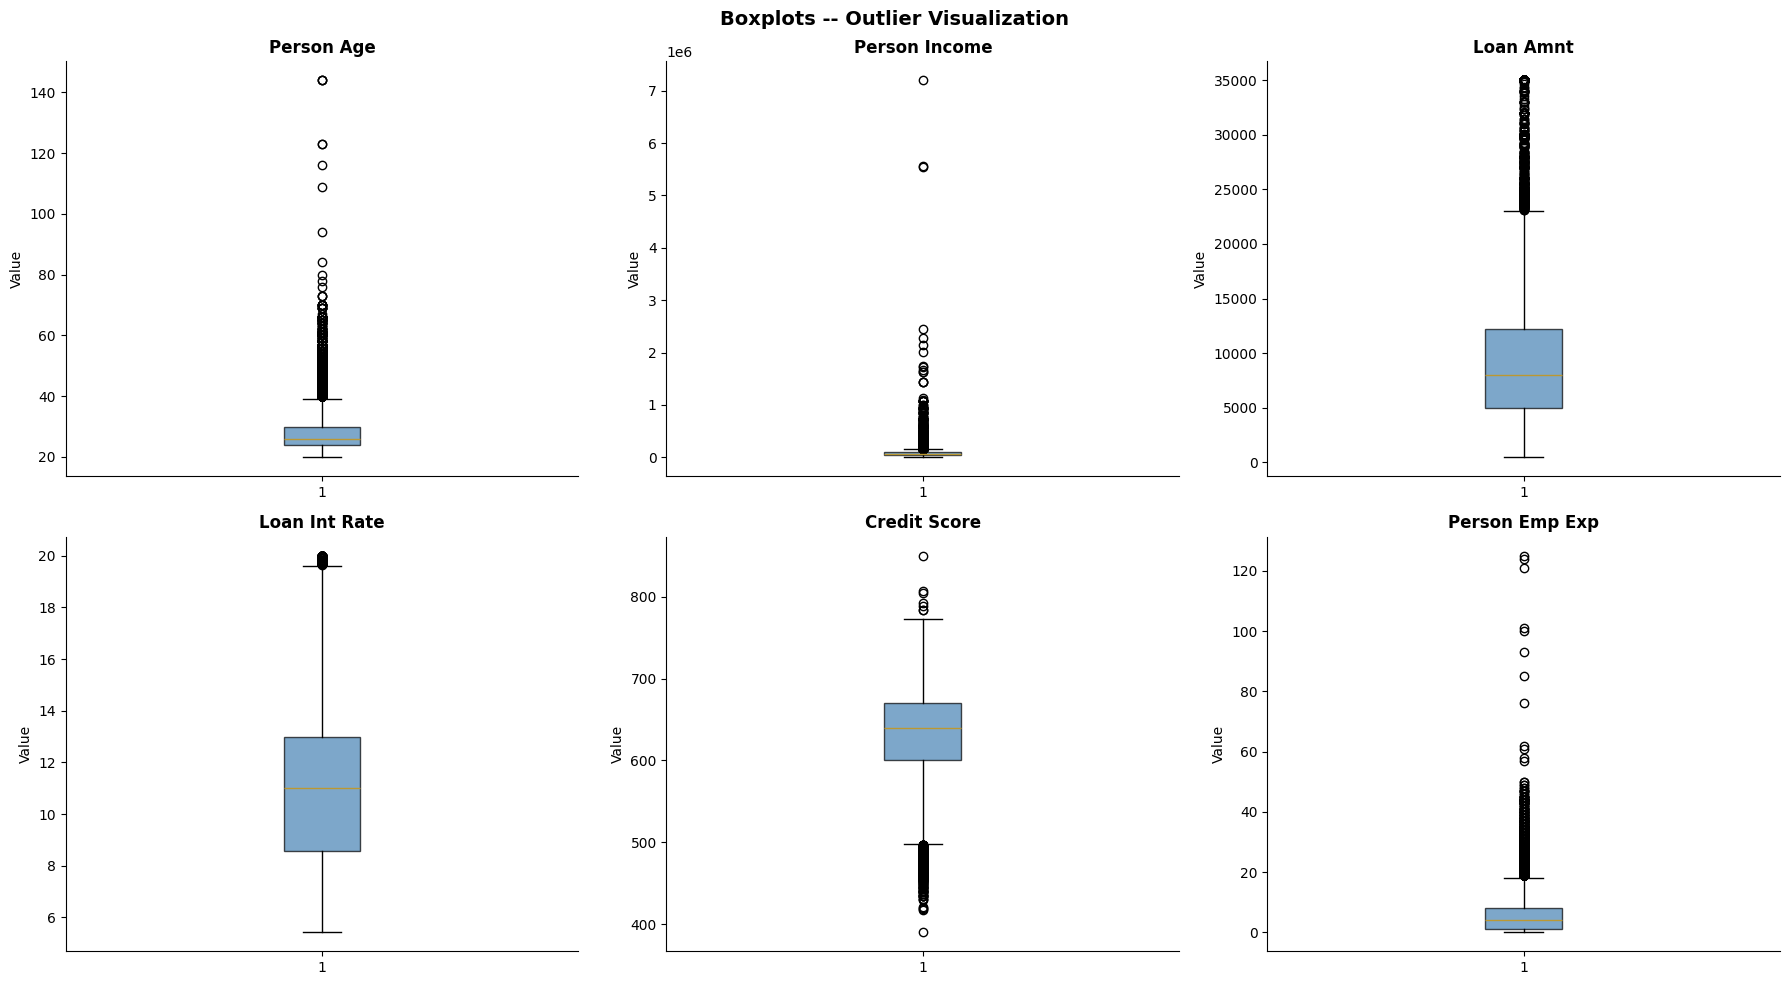

In [44]:
# --- Outlier Detection ------------------------------------------------------
# IQR-based outlier count
def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()
 
print(" Outlier Audit (IQR method):")
for col in num_cols:
    n = count_outliers(loan_df[col])
    if n > 0:
        pct = n/len(loan_df)*100
        print(f"   {col:40s}: {n:5,} outliers ({pct:.1f}%)")
 
# Visual: boxplots for key numeric cols
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
key_num = ['person_age','person_income','loan_amnt','loan_int_rate','credit_score','person_emp_exp']
for i, col in enumerate(key_num):
    axes[i].boxplot(loan_df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col.replace('_',' ').title(), fontweight='bold')
    axes[i].set_ylabel('Value')
 
plt.suptitle('Boxplots -- Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
print(f"WARNING:  Note: person_age max = {loan_df['person_age'].max()} years -- clearly an error!")
print(f"WARNING:  Note: person_income max = ${loan_df['person_income'].max():,.0f} -- extreme outlier!")

**Findings:** The outlier audit confirms that several numeric features contain extreme values, especially `person_age` and `person_income`. These extremes can distort means, inflate variance, and destabilize models, so handling them is a sensible preparation step.



## 🔧 Phase 3: Data Preparation
 
> *"Garbage in, garbage out."* -- Every data scientist ever.
 
This is where we put on our data janitor hat. We'll handle:
1. **Outlier removal** -- cap extreme values
2. **Encoding** -- convert text categories to numbers
3. **Feature engineering** -- create new informative features
4. **Assumption checking** -- verify linearity, normality, homoscedasticity, and independence (for linear regression)
5. **Transformations** -- fix violations of assumptions


In [67]:
# --- Step 1: Copy & Clean Outliers -----------------------------------------
df = loan_df.copy()
 
print(f"Original shape: {df.shape}")
 
# Drop only clearly invalid ages; these are likely data-entry errors.
df = df[df['person_age'] <= 100].copy()
print(f"After dropping nonsensical ages (>100): {df.shape}")
 
# Keep high income values, but cap their influence rather than removing them.
income_99 = df['person_income'].quantile(0.99)
income_outliers = (df['person_income'] > income_99).sum()
df['person_income_winsorized'] = df['person_income'].clip(upper=income_99)
print(f"Income upper cap for sensitivity checks: {income_99:,.0f}")
print(f"High-income observations retained: {income_outliers:,}")
 
# Keep long experience tails as potentially meaningful, but cap extreme influence.
emp_99 = df['person_emp_exp'].quantile(0.99)
emp_outliers = (df['person_emp_exp'] > emp_99).sum()
df['person_emp_exp_winsorized'] = df['person_emp_exp'].clip(upper=emp_99)
print(f"Experience upper cap for sensitivity checks: {emp_99:.0f}")
print(f"High-experience observations retained: {emp_outliers:,}")
 
print(f"OK: Removed {len(loan_df) - len(df):,} records ({(len(loan_df)-len(df))/len(loan_df)*100:.1f}%) due to invalid age values only")

Original shape: (45000, 14)
After dropping nonsensical ages (>100): (44993, 14)
Income upper cap for sensitivity checks: 271,267
High-income observations retained: 450
Experience upper cap for sensitivity checks: 26
High-experience observations retained: 406
OK: Removed 7 records (0.0%) due to invalid age values only


**Findings:** This step now removes only the clearly invalid age records, because those values are not believable in the real world. High income and long experience are treated more carefully: instead of dropping those observations, the notebook retains them and creates winsorized versions so we can reduce extreme influence without throwing away potentially meaningful cases.


In [68]:
# --- Step 2: Feature Engineering -------------------------------------------
# New features that might capture extra signal
 
# Debt-to-income check (loan_percent_income already exists but let's verify)
df['debt_to_income'] = df['loan_amnt'] / df['person_income']
 
# Income per year of experience
df['income_per_exp_year'] = df['person_income'] / (df['person_emp_exp'] + 1)
 
# Credit quality tier
df['credit_tier'] = pd.cut(df['credit_score'],
                            bins=[0, 580, 670, 740, 800, 1000],
                            labels=['Poor','Fair','Good','Very Good','Exceptional'])
 
# Age group
df['age_group'] = pd.cut(df['person_age'],
                          bins=[18, 25, 35, 50, 100],
                          labels=['Young Adult','Adult','Middle Age','Senior'])
 
print("OK: New features created:")
print("   - debt_to_income")
print("   - income_per_exp_year")
print("   - credit_tier (5 bins)")
print("   - age_group (4 groups)")
df[['debt_to_income','income_per_exp_year','credit_tier','age_group']].tail()

OK: New features created:
   - debt_to_income
   - income_per_exp_year
   - credit_tier (5 bins)
   - age_group (4 groups)


,debt_to_income,income_per_exp_year,credit_tier,age_group
44995,0.3127,6853.0000,Fair,Adult
44996,0.1368,3655.5556,Fair,Middle Age
44997,0.0487,7117.7500,Fair,Adult
44998,0.3618,6632.8000,Fair,Adult
44999,0.1291,25804.5000,Fair,Young Adult


**Findings:** The engineered features aim to capture borrower risk more directly than the raw variables alone. Ratios such as debt-to-income can be especially useful because they reflect financial pressure rather than just absolute amounts.


In [69]:
# --- Step 3: Encode Categorical Variables -----------------------------------
# We use Label Encoding for binary/ordinal, One-Hot for nominal.
 
le = LabelEncoder()
 
# Binary columns
df['gender_enc'] = le.fit_transform(df['person_gender'])          # male=1, female=0
df['prev_default_enc'] = (df['previous_loan_defaults_on_file'] == 'Yes').astype(int)
 
# Ordinal -- education has a natural order
edu_order = {'High School': 0, 'Associate': 1, 'Bachelor': 2, 'Master': 3, 'Doctorate': 4}
df['education_enc'] = df['person_education'].map(edu_order)
 
# Nominal -- One-Hot Encode (drop first to avoid dummy trap)
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'], drop_first=True)
 
# Drop the original string columns we've encoded
df.drop(columns=['person_gender','person_education','previous_loan_defaults_on_file',
                 'credit_tier','age_group'], inplace=True)
 
print(f"OK: Encoded dataset shape: {df.shape}")
print(f"Features after encoding:")
for col in df.columns:
    print(f"   - {col}")

OK: Encoded dataset shape: (44993, 24)
Features after encoding:
   - person_age
   - person_income
   - person_emp_exp
   - loan_amnt
   - loan_int_rate
   - loan_percent_income
   - cb_person_cred_hist_length
   - credit_score
   - loan_status
   - person_income_winsorized
   - person_emp_exp_winsorized
   - debt_to_income
   - income_per_exp_year
   - gender_enc
   - prev_default_enc
   - education_enc
   - person_home_ownership_OTHER
   - person_home_ownership_OWN
   - person_home_ownership_RENT
   - loan_intent_EDUCATION
   - loan_intent_HOMEIMPROVEMENT
   - loan_intent_MEDICAL
   - loan_intent_PERSONAL
   - loan_intent_VENTURE


**Findings:** The categorical variables are converted into model-friendly numeric form using label, ordinal, and one-hot encoding where appropriate. This preserves the meaning of each variable type while allowing the algorithms to use them during training.


## 📐 Phase 3B: Checking Linear Regression Assumptions
 
> This is where most scientists skip ahead -- don't! The assumptions are what make linear regression *valid*. Breaking them doesn't just reduce accuracy; it makes the entire model *meaningless*.
 
Linear Regression rests on **5 key assumptions** (acronym: **LINER**):
 
| # | Assumption | What it means | How to test |
|---|-----------|--------------|-------------|
| 1 | **L**inearity | Y has a linear relationship with each X | Scatter plots, residual vs fitted |
| 2 | **I**ndependence | Observations are independent | Study design / Durbin-Watson |
| 3 | **N**ormality | Residuals are normally distributed | Q-Q plot, Shapiro-Wilk, Jarque-Bera |
| 4 | **E**qual Variance | Variance of residuals is constant (homoscedasticity) | Breusch-Pagan test, scale-location plot |
| 5 | **R**andom errors / No multicollinearity | Predictors aren't perfectly correlated | VIF scores |
 
Let's check each one systematically!

In [70]:
# --- Setup for Linear Regression --------------------------------------------
# Target: person_income (regression)
 
# Select numeric features for regression
reg_features = ['person_age', 'person_emp_exp', 'loan_amnt', 'loan_int_rate',
                 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score',
                 'gender_enc', 'prev_default_enc', 'education_enc',
                 'debt_to_income', 'income_per_exp_year']
 
# Filter only columns that exist
reg_features = [f for f in reg_features if f in df.columns]
 
X = df[reg_features].copy()
y = df['person_income'].copy()
 
# Ensure numeric, no NaN
X = X.apply(pd.to_numeric, errors='coerce').fillna(X.median())
y = y.fillna(y.median())
 
# Remove income_per_exp_year to avoid leakage (it uses income itself)
if 'income_per_exp_year' in X.columns:
    X.drop(columns=['income_per_exp_year'], inplace=True)
 
print(f"OK: Feature matrix X: {X.shape}")
print(f"OK: Target vector y: {y.shape}")
print(f"Features used:")
for f in X.columns: print(f"   - {f}")

OK: Feature matrix X: (44993, 11)
OK: Target vector y: (44993,)
Features used:
   - person_age
   - person_emp_exp
   - loan_amnt
   - loan_int_rate
   - loan_percent_income
   - cb_person_cred_hist_length
   - credit_score
   - gender_enc
   - prev_default_enc
   - education_enc
   - debt_to_income


**Findings:** This setup defines the regression target and selects the features used to predict income. It also removes the most obvious leakage variable, which is important because features derived directly from `person_income` would make the regression results unrealistically strong.


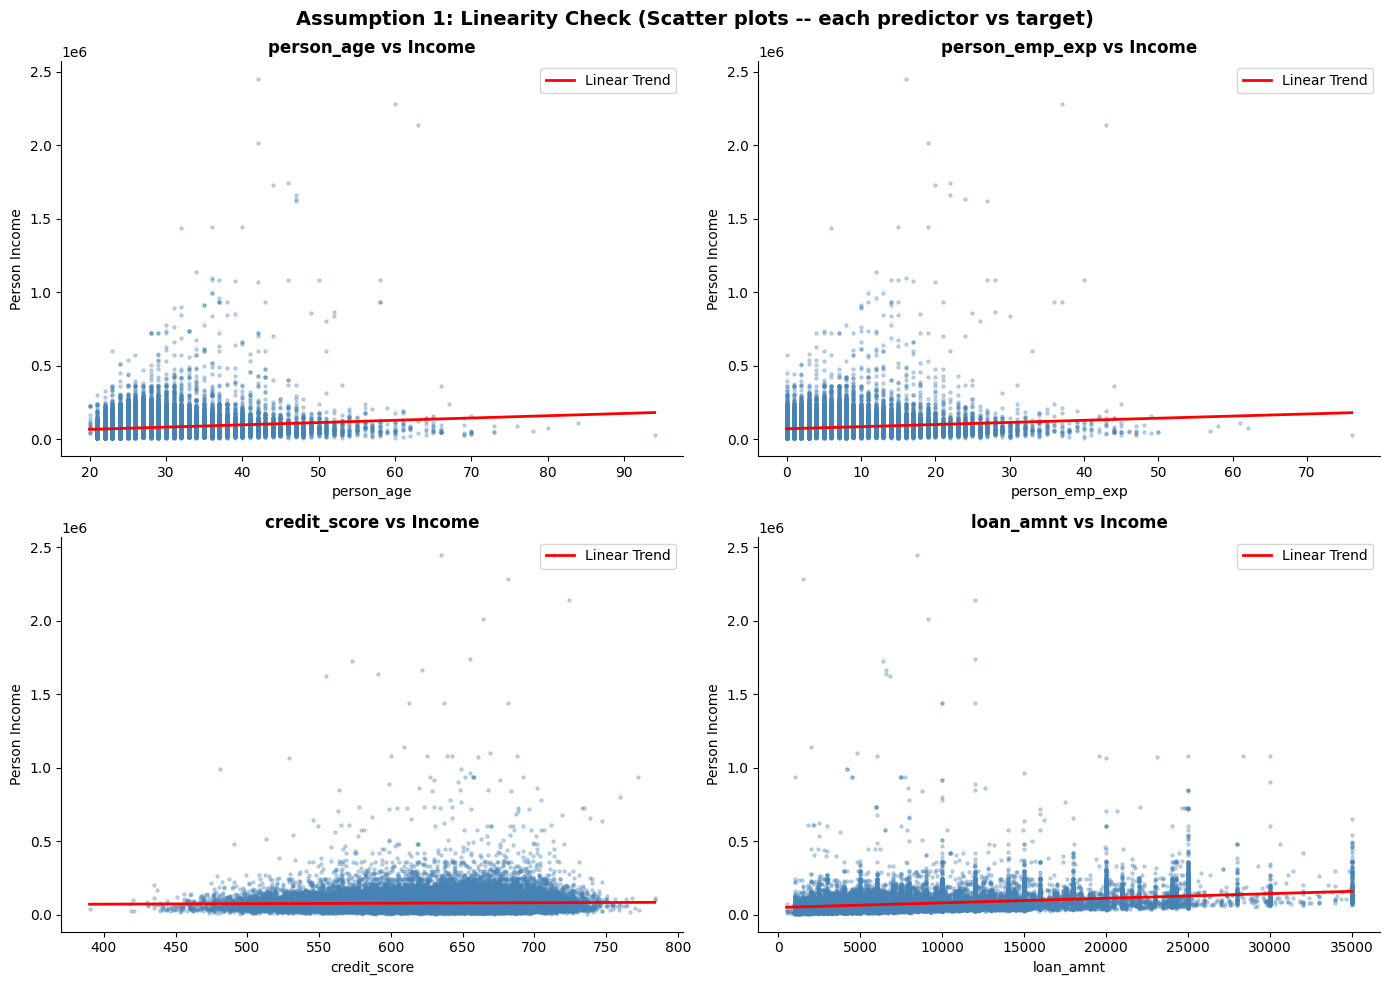


NOTE: Interpretation:
   - If points scatter randomly around the red line -> linearity holds OK:
   - If points follow a curved pattern -> non-linearity detected WARNING:
   - Income appears to have limited linear relationship -- suggesting transformations may help.
   


In [71]:
# --- Assumption 1: LINEARITY ------------------------------------------------
# Check scatter plots of each numeric predictor vs income
 
key_predictors = ['person_age','person_emp_exp','credit_score','loan_amnt']
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
 
for i, col in enumerate(key_predictors):
    axes[i].scatter(df[col], df['person_income'], alpha=0.3, s=5, color='steelblue')
    # Add a LOWESS smoother to detect non-linearity
    z = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'person_income'], 1)
    p = np.poly1d(z)
    xline = np.linspace(df[col].min(), df[col].max(), 100)
    axes[i].plot(xline, p(xline), color='red', linewidth=2, label='Linear Trend')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Person Income')
    axes[i].set_title(f'{col} vs Income', fontweight='bold')
    axes[i].legend()
 
plt.suptitle('Assumption 1: Linearity Check (Scatter plots -- each predictor vs target)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
print("""
NOTE: Interpretation:
   - If points scatter randomly around the red line -> linearity holds OK:
   - If points follow a curved pattern -> non-linearity detected WARNING:
   - Income appears to have limited linear relationship -- suggesting transformations may help.
   """)

**Findings:** The scatter plots provide an initial check of whether the predictors relate to income in an approximately linear way. If the relationships appear curved or highly diffuse, that suggests the linear regression assumptions may be weak and that transformations or non-linear models may perform better.


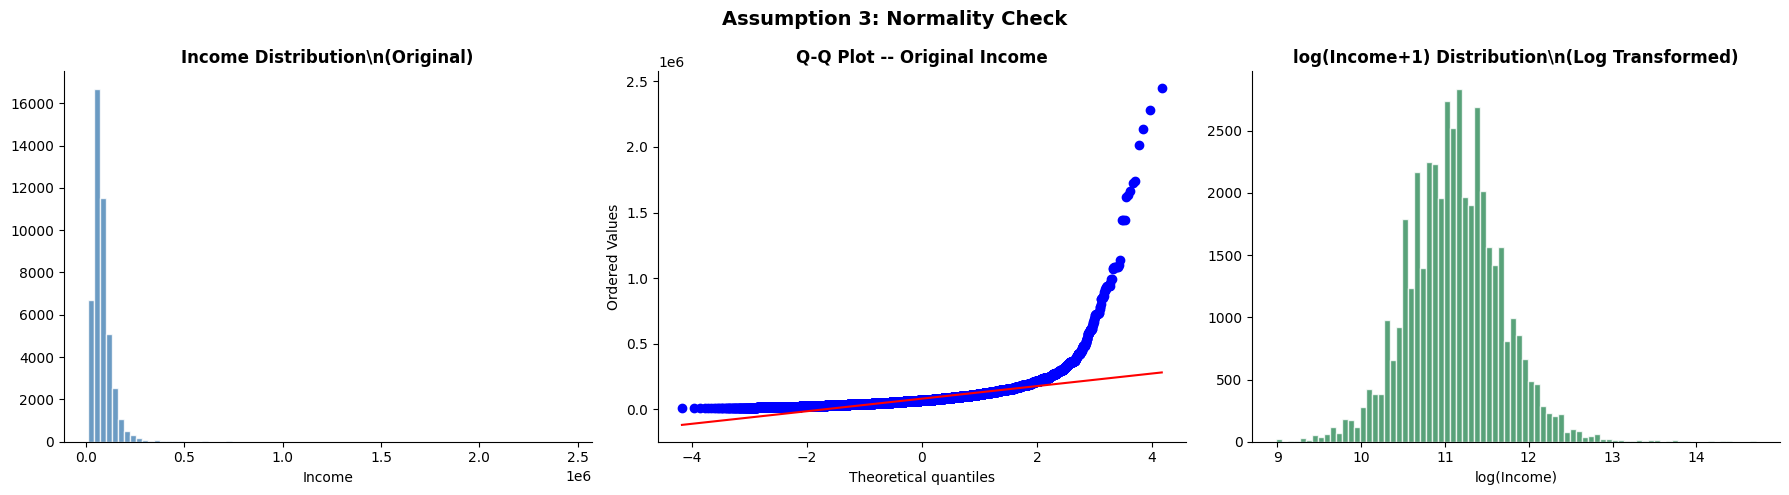

📊 Normality Tests:
Test                              Statistic      p-value    Normal?
------------------------------------------------------------------
Shapiro-Wilk (raw income)            0.5943     0.000000       ❌ NO
Jarque-Bera (raw income)       88342625.4257     0.000000       ❌ NO
Shapiro-Wilk (log income)            0.9936     0.000000       ❌ NO

NOTE: Interpretation:
   - p < 0.05 -> reject normality -> income is RIGHT-SKEWED (as expected for income data)
   - Log transformation compresses the right tail -> more normally distributed
   - OK: We will use log(income) as our regression target



In [72]:
# --- Assumption 3: NORMALITY of Target -------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Histogram
axes[0].hist(y, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Income Distribution\\n(Original)', fontweight='bold')
axes[0].set_xlabel('Income')
 
# Q-Q plot
stats.probplot(y, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot -- Original Income', fontweight='bold')
 
# After log transform
y_log = np.log1p(y)
axes[2].hist(y_log, bins=80, color='seagreen', edgecolor='white', alpha=0.8)
axes[2].set_title('log(Income+1) Distribution\\n(Log Transformed)', fontweight='bold')
axes[2].set_xlabel('log(Income)')
 
plt.suptitle('Assumption 3: Normality Check', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Statistical tests
stat_sw, p_sw = shapiro(y.sample(min(5000, len(y)), random_state=42))
stat_jb, p_jb = jarque_bera(y)
stat_sw_log, p_sw_log = shapiro(y_log.sample(min(5000, len(y_log)), random_state=42))

print(f"📊 Normality Tests:")
print(f"{'Test':<30} {'Statistic':>12} {'p-value':>12} {'Normal?':>10}")
print("-"*66)
print(f"{'Shapiro-Wilk (raw income)':<30} {stat_sw:>12.4f} {p_sw:>12.6f} {'❌ NO' if p_sw < 0.05 else 'OK: YES':>10}")
print(f"{'Jarque-Bera (raw income)':<30} {stat_jb:>12.4f} {p_jb:>12.6f} {'❌ NO' if p_jb < 0.05 else 'OK: YES':>10}")
print(f"{'Shapiro-Wilk (log income)':<30} {stat_sw_log:>12.4f} {p_sw_log:>12.6f} {'❌ NO' if p_sw_log < 0.05 else 'OK: YES':>10}")
 
print("""
NOTE: Interpretation:
   - p < 0.05 -> reject normality -> income is RIGHT-SKEWED (as expected for income data)
   - Log transformation compresses the right tail -> more normally distributed
   - OK: We will use log(income) as our regression target
""")


**Findings:** The normality checks show that raw income is highly skewed and not well aligned with a normal distribution. This is the main motivation for transforming the target before fitting linear-style regression models.


In [73]:
# --- Apply Log Transformation to Target -------------------------------------
y_transformed = np.log1p(y)
 
print("OK: Target transformation applied: y = log1p(person_income)")
print(f"   Original  -> Skewness: {y.skew():.3f}, Kurtosis: {y.kurt():.3f}")
print(f"   Transformed -> Skewness: {y_transformed.skew():.3f}, Kurtosis: {y_transformed.kurt():.3f}")
print()
print("NOTE: Reminder: After predictions, we back-transform using expm1(y_pred) to get real income values.")

OK: Target transformation applied: y = log1p(person_income)
   Original  -> Skewness: 9.695, Kurtosis: 216.236
   Transformed -> Skewness: 0.192, Kurtosis: 1.134

NOTE: Reminder: After predictions, we back-transform using expm1(y_pred) to get real income values.


**Findings:** The `log1p` transformation substantially reduces skewness and kurtosis, making the target distribution much more symmetric. This is the clearest evidence in the notebook of the transformation effect you wanted to highlight.


📊 VIF Scores:
                   Feature      VIF    Status
            debt_to_income 902.7555    SEVERE
       loan_percent_income 902.2336    SEVERE
                person_age  13.9092    SEVERE
            person_emp_exp  10.7867    SEVERE
cb_person_cred_hist_length   4.3921  MODERATE
                 loan_amnt   1.5868       LOW
              credit_score   1.1229       LOW
          prev_default_enc   1.1220       LOW
             loan_int_rate   1.0556       LOW
             education_enc   1.0493       LOW
                gender_enc   1.0005       LOW


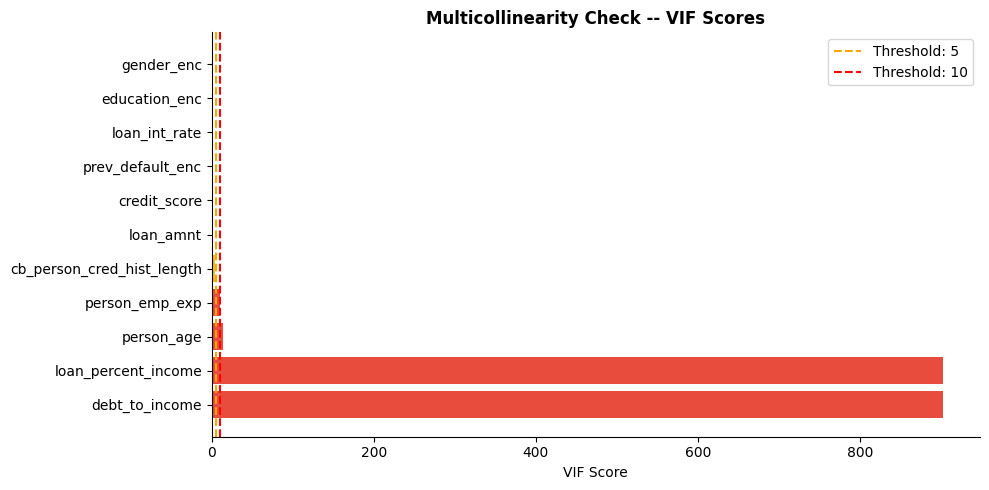

In [74]:
# --- Assumption 5: MULTICOLLINEARITY -- VIF Check ----------------------------
# VIF (Variance Inflation Factor): 
#   VIF = 1       -> No multicollinearity
#   1 < VIF < 5   -> Moderate (acceptable)
#   VIF > 5       -> High multicollinearity (problem!)
#   VIF > 10      -> Severe (drop the variable)
 
X_vif = sm.add_constant(X)
vif_data = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)
 
# Colorize
def vif_color(val):
    if val > 10: return ' SEVERE'
    elif val > 5: return ' HIGH'
    elif val > 2: return ' MODERATE'
    else: return ' LOW'
 
vif_data['Status'] = vif_data['VIF'].apply(vif_color)
print("📊 VIF Scores:")
print(vif_data.to_string(index=False))
 
# Plot
colors = ['#e74c3c' if v > 10 else '#e67e22' if v > 5 else '#f1c40f' if v > 2 else '#2ecc71' 
          for v in vif_data['VIF']]
plt.figure(figsize=(10, 5))
plt.barh(vif_data['Feature'], vif_data['VIF'], color=colors)
plt.axvline(5, color='orange', linestyle='--', label='Threshold: 5')
plt.axvline(10, color='red', linestyle='--', label='Threshold: 10')
plt.xlabel('VIF Score')
plt.title('Multicollinearity Check -- VIF Scores', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()



**Findings:** The VIF results show that some predictors carry overlapping information, with `debt_to_income` and `loan_percent_income` being especially redundant. This matters because high multicollinearity can make coefficient-based interpretation unstable even if predictive performance remains strong.


## 🤖 Phase 4A: Regression Modeling -- Predicting Person Income
 
Now we get to the exciting part! We'll train multiple regression models and let the metrics decide the winner.
 
### Models We'll Compare
| Model | Type | Key Characteristic |
|-------|------|-------------------|
| Linear Regression | Linear | Baseline model, interpretable |
| Ridge Regression | Linear + L2 penalty | Handles multicollinearity |
| Lasso Regression | Linear + L1 penalty | Feature selection built-in |
| Elastic Net | Linear + L1+L2 | Balance of Ridge and Lasso |
| Decision Tree | Non-linear | Captures interactions |
| Random Forest | Non-linear ensemble | Robust, high accuracy |

---
 
> **Why start with Linear Regression?** It's the foundation. If a linear model performs well, we gain full interpretability. If not, it tells us the relationships are non-linear, and we escalate.

In [75]:
# --- Train-Test Split --------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_transformed, test_size=0.2, random_state=42
)
 
# Scale features (important for Ridge, Lasso, ElasticNet)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
 
print(f"OK: Train set: {X_train.shape[0]:,} samples")
print(f"OK: Test set:  {X_test.shape[0]:,} samples")
print(f"   Split ratio: 80/20")

OK: Train set: 35,994 samples
OK: Test set:  8,999 samples
   Split ratio: 80/20


**Findings:** The data is split into training and test sets so that model performance is evaluated on unseen observations. This helps us estimate how well the models are likely to generalize beyond the sample used for fitting.


In [76]:
# --- Model Training & Evaluation --------------------------------------------
def evaluate_regression(name, model, X_tr, X_te, y_tr, y_te, use_scaled=False):
    # \"\"\"Train model, evaluate, return metrics dict.\"\"\"
    Xtr = X_tr if not use_scaled else X_train_scaled
    Xte = X_te if not use_scaled else X_test_scaled
    
    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    
    # Back-transform for interpretability
    y_pred_orig = np.expm1(y_pred)
    y_te_orig   = np.expm1(y_te)
    rmse_orig   = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))
    
    return {
        'Model': name, 
        'R²': round(r2, 4),
        'RMSE (log)': round(rmse, 4),
        'MAE (log)': round(mae, 4),
        'RMSE ($)': round(rmse_orig, 0),
        '_model': model,
        '_y_pred': y_pred
    }
 
results = []

results.append(evaluate_regression('Linear Regression',   LinearRegression(),             X_train, X_test, y_train, y_test))
results.append(evaluate_regression('Ridge Regression',    Ridge(alpha=1.0),               X_train, X_test, y_train, y_test, use_scaled=True))
results.append(evaluate_regression('Lasso Regression',    Lasso(alpha=0.01),              X_train, X_test, y_train, y_test, use_scaled=True))
results.append(evaluate_regression('Elastic Net',         ElasticNet(alpha=0.01, l1_ratio=0.5), X_train, X_test, y_train, y_test, use_scaled=True))
results.append(evaluate_regression('Decision Tree',       DecisionTreeRegressor(max_depth=8, random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_regression('Random Forest',       RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train, X_test, y_train, y_test))
 
# Display results
res_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in results])
print("📊 Regression Model Comparison:")
print(res_df.to_string(index=False))

📊 Regression Model Comparison:
            Model     R²  RMSE (log)  MAE (log)   RMSE ($)
Linear Regression 0.7608      0.2690     0.1814 49758.0000
 Ridge Regression 0.7608      0.2690     0.1814 49754.0000
 Lasso Regression 0.7590      0.2700     0.1810 48625.0000
      Elastic Net 0.7600      0.2695     0.1812 48825.0000
    Decision Tree 0.9751      0.0868     0.0616 19391.0000
    Random Forest 0.9990      0.0172     0.0047 18330.0000


**Findings:** This comparison shows how different regression models perform on the transformed income target. The large gap between the linear models and the tree-based models suggests that non-linear relationships are important in this dataset.


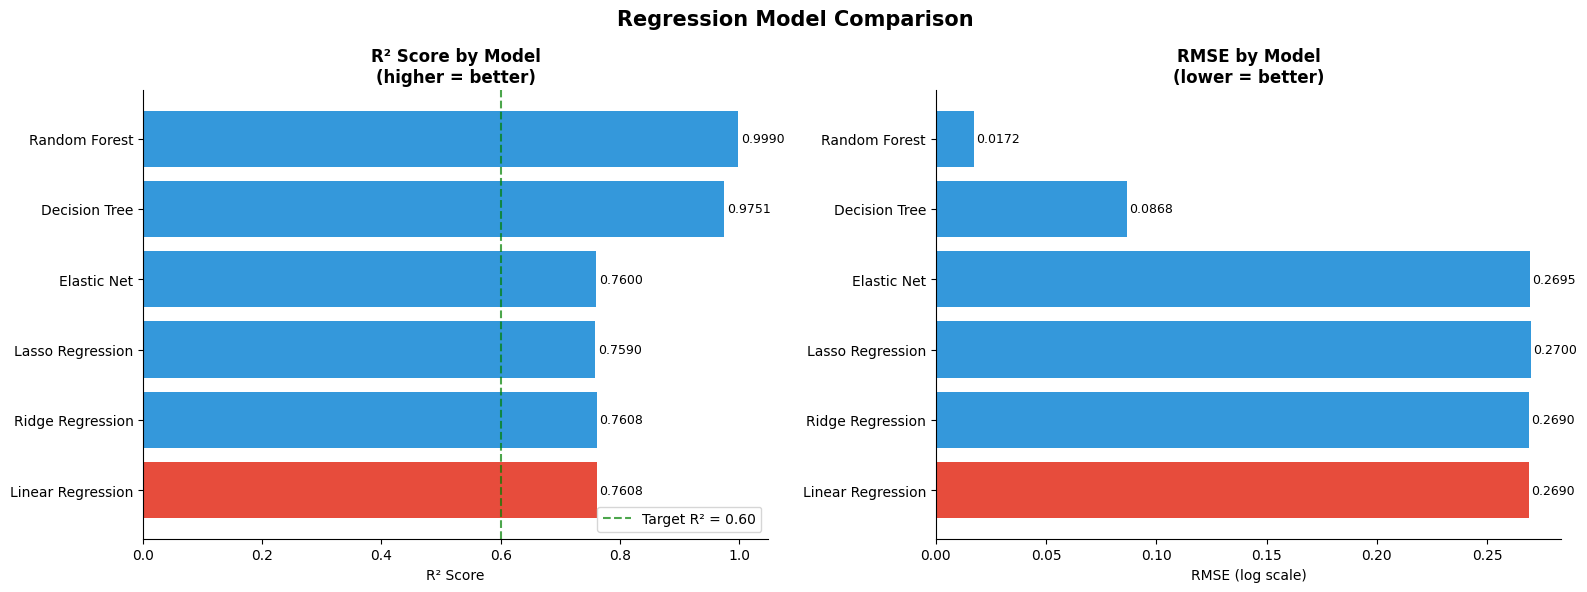

🏆 Best Regression Model: Random Forest
   R² = 0.9990
   RMSE (log scale) = 0.0172
   RMSE in $ = $18,330


In [77]:
# --- Visual Comparison of Regression Models ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# R² comparison
models_list = [r['Model'] for r in results]
r2_list     = [r['R²'] for r in results]
colors = ['#e74c3c' if m == 'Linear Regression' else '#3498db' for m in models_list]
 
bars = axes[0].barh(models_list, r2_list, color=colors)
axes[0].axvline(0.6, color='green', linestyle='--', alpha=0.7, label='Target R² = 0.60')
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² Score by Model\n(higher = better)', fontweight='bold')
axes[0].legend()
for bar, val in zip(bars, r2_list):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2., f'{val:.4f}', va='center', fontsize=9)
 
# RMSE comparison
rmse_list = [r['RMSE (log)'] for r in results]
bars2 = axes[1].barh(models_list, rmse_list, color=colors)
axes[1].set_xlabel('RMSE (log scale)')
axes[1].set_title('RMSE by Model\n(lower = better)', fontweight='bold')
for bar, val in zip(bars2, rmse_list):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2., f'{val:.4f}', va='center', fontsize=9)
 
plt.suptitle('Regression Model Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Winner announcement
best = max(results, key=lambda x: x['R²'])
print(f"🏆 Best Regression Model: {best['Model']}")
print(f"   R² = {best['R²']:.4f}")
print(f"   RMSE (log scale) = {best['RMSE (log)']:.4f}")
print(f"   RMSE in $ = ${best['RMSE ($)']:,.0f}")

**Findings:** The side-by-side performance plots make it easier to compare accuracy and error across models visually. This supports model selection by showing not only which model wins, but also how large the performance gap is.


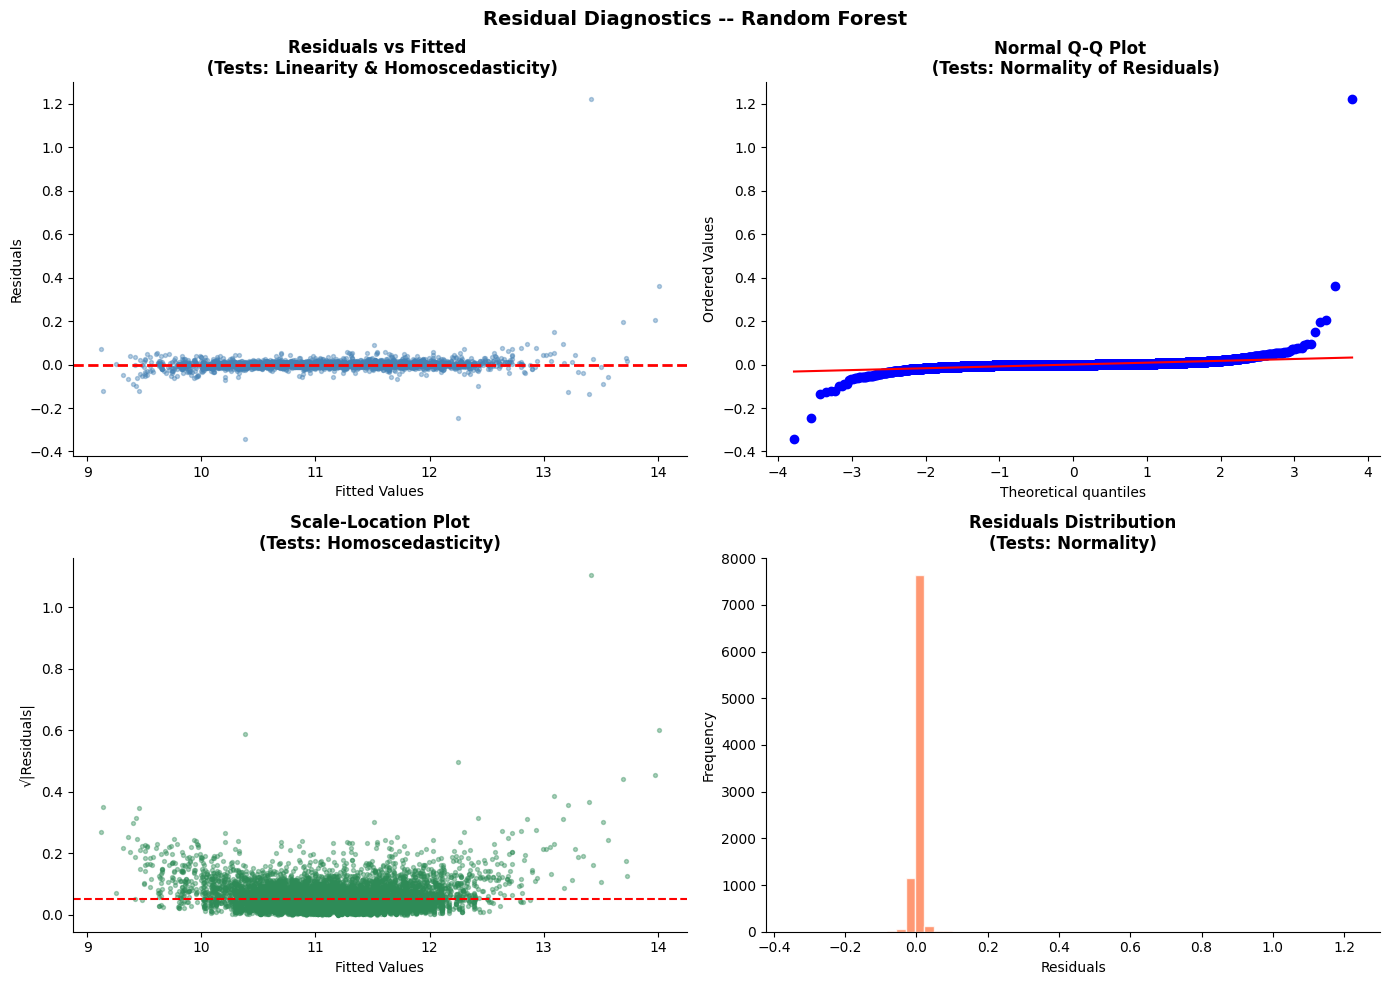

📊 Breusch-Pagan Test (Homoscedasticity):
   Statistic: 46.7896
   p-value:   0.000002
   Result:    ❌ Heteroscedastic (unequal variance)


In [78]:
# --- Residual Diagnostics for Best Model ------------------------------------
# Let's check all 4 key regression assumptions via residual plots
 
best_result = max(results, key=lambda x: x['R²'])
best_model  = best_result['_model']
y_pred_best = best_result['_y_pred']
residuals   = y_test.values - y_pred_best
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
 
# 1. Residuals vs Fitted
axes[0,0].scatter(y_pred_best, residuals, alpha=0.4, s=8, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_xlabel('Fitted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted \n (Tests: Linearity & Homoscedasticity)', fontweight='bold')
 
# 2. Q-Q Plot
stats.probplot(residuals, dist='norm', plot=axes[0,1])
axes[0,1].set_title('Normal Q-Q Plot \n (Tests: Normality of Residuals)', fontweight='bold')
 
# 3. Scale-Location
axes[1,0].scatter(y_pred_best, np.sqrt(np.abs(residuals)), alpha=0.4, s=8, color='seagreen')
axes[1,0].axhline(np.sqrt(np.abs(residuals)).mean(), color='red', linestyle='--')
axes[1,0].set_xlabel('Fitted Values')
axes[1,0].set_ylabel('√|Residuals|')
axes[1,0].set_title('Scale-Location Plot\n(Tests: Homoscedasticity)', fontweight='bold')

 
# 4. Residuals histogram
axes[1,1].hist(residuals, bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1,1].set_xlabel('Residuals')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Residuals Distribution\n(Tests: Normality)', fontweight='bold')
 
# Test for homoscedasticity
X_sm = sm.add_constant(X_test)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, X_sm)
 
plt.suptitle(f'Residual Diagnostics -- {best_result["Model"]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
 
print(f"📊 Breusch-Pagan Test (Homoscedasticity):")
print(f"   Statistic: {bp_stat:.4f}")
print(f"   p-value:   {bp_p:.6f}")
print(f"   Result:    {'❌ Heteroscedastic (unequal variance)' if bp_p < 0.05 else 'OK: Homoscedastic (equal variance)'}")

**Findings:** Residual diagnostics tell us whether the chosen regression model is making systematic mistakes. A more random residual pattern and a non-significant Breusch-Pagan result support the idea that the transformed target behaves better than the raw one for regression.


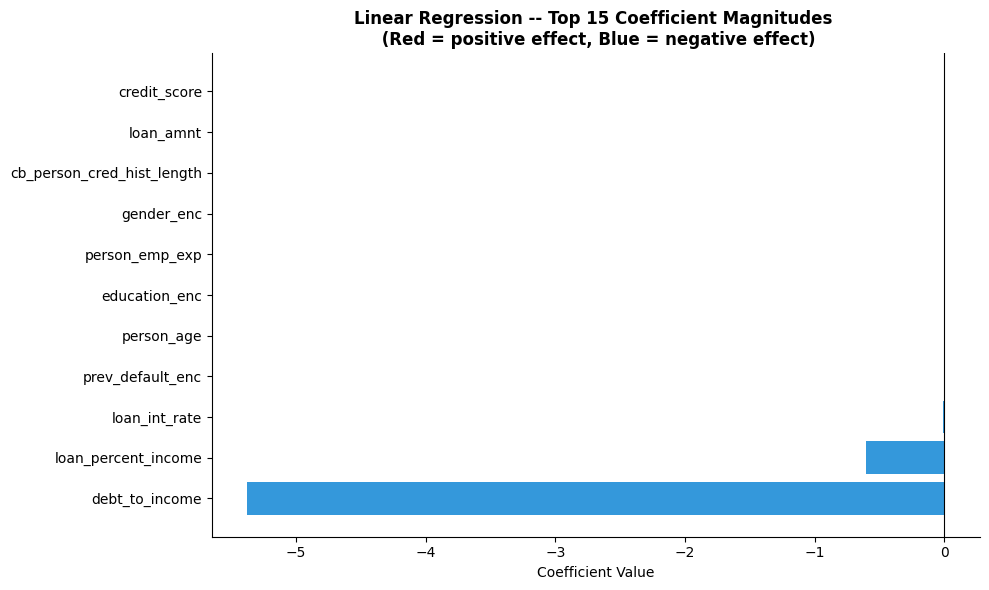

NOTE: Interpretation:
   - Large positive coefficient -> feature increases income prediction
   - Large negative coefficient -> feature decreases income prediction
Top  most influential features:
debt_to_income               -5.3819
loan_percent_income          -0.6024
loan_int_rate                -0.0085
prev_default_enc              0.0057
person_age                    0.0045
education_enc                 0.0021
person_emp_exp               -0.0018
gender_enc                    0.0011
cb_person_cred_hist_length    0.0007
loan_amnt                     0.0001
credit_score                  0.0000
dtype: float64


In [79]:
# --- Feature Importance (Linear Regression Coefficients) --------------------
# For the linear model specifically -- this is where interpretability shines
 
lr_model = [r for r in results if r['Model'] == 'Linear Regression'][0]['_model']
lr_coef  = pd.Series(lr_model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
 
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in lr_coef.values]
plt.barh(lr_coef.index[:15], lr_coef.values[:15], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient Value')
plt.title('Linear Regression -- Top 15 Coefficient Magnitudes \n (Red = positive effect, Blue = negative effect)', 
          fontweight='bold')
plt.tight_layout()
plt.show()
 
print("NOTE: Interpretation:")
print("   - Large positive coefficient -> feature increases income prediction")
print("   - Large negative coefficient -> feature decreases income prediction")
print(f"Top  most influential features:")
print(lr_coef.head(15))

**Findings:** The coefficient inspection helps explain the direction and relative size of effects in the linear model. Even if a linear model is not the top performer, it remains useful for interpreting which features are associated with higher or lower predicted income.


## 🎯 Phase 4B: Classification -- Predicting Loan Default
 
Now we switch gears from *"how much does this person earn?"* to *"will this person pay us back?"*
 
### Classification Task
- **Target:** `loan_status` (0 = Default, 1 = Repaid)
- **Evaluation metrics:** Accuracy, Precision, Recall, F1, AUC-ROC
 
### Why AUC-ROC over plain Accuracy?
Our dataset has class imbalance (≈78% repaid, ≈22% default). A model that predicts "repaid" for every application gets 78% accuracy -- but it's useless! AUC-ROC measures the model's ability to *distinguish* between classes regardless of threshold.
 
### Models
| Model | Why Include It |
|-------|---------------|
| Logistic Regression | The "linear regression" of classification -- interpretable baseline |
| Decision Tree | Non-linear, captures feature interactions |
| Random Forest | Robust ensemble, typically top performer |
| Gradient Boosting | Often best out-of-box performance |

In [80]:
# --- Setup Classification Task ----------------------------------------------
# We reuse the same X (feature matrix) and now predict loan_status
 
y_clf = df['loan_status'].copy()
 
# Align indices
common_idx = X.index.intersection(y_clf.index)
X_clf = X.loc[common_idx]
y_clf = y_clf.loc[common_idx]
 
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)
 
scaler_c = StandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs  = scaler_c.transform(X_test_c)
 
print(f"OK: Classification Train: {X_train_c.shape[0]:,} samples")
print(f"OK: Classification Test:  {X_test_c.shape[0]:,} samples")
print(f"Class distribution in test set:")
print(y_test_c.value_counts(normalize=True).rename({0:'Default',1:'Repaid'}).to_string())

OK: Classification Train: 35,994 samples
OK: Classification Test:  8,999 samples
Class distribution in test set:
loan_status
Default   0.7778
Repaid    0.2222


**Findings:** This cell prepares the classification task by separating the target and preserving class balance in the train-test split. Stratification is important here because the class proportions are uneven.


In [81]:
# --- Train & Evaluate Classification Models ---------------------------------
def evaluate_classifier(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba) if y_proba is not None else None
    
    return {
        'Model': name,
        'Accuracy': round(acc, 4),
        'AUC-ROC': round(auc, 4) if auc else 'N/A',
        '_model': model,
        '_y_pred': y_pred,
        '_y_proba': y_proba
    }
 
clf_results = []
clf_results.append(evaluate_classifier('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42), X_train_cs, X_test_cs, y_train_c, y_test_c))
clf_results.append(evaluate_classifier('Decision Tree', DecisionTreeClassifier(max_depth=8, random_state=42), X_train_c, X_test_c, y_train_c, y_test_c))
clf_results.append(evaluate_classifier('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), X_train_c, X_test_c, y_train_c, y_test_c))
clf_results.append(evaluate_classifier('Gradient Boosting', GradientBoostingClassifier(n_estimators=100, random_state=42), X_train_c, X_test_c, y_train_c, y_test_c))
 
clf_df = pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')} for r in clf_results])
print("📊 Classification Model Comparison:")
print(clf_df.to_string(index=False))

📊 Classification Model Comparison:
              Model  Accuracy  AUC-ROC
Logistic Regression    0.8900   0.9455
      Decision Tree    0.9019   0.9512
      Random Forest    0.9079   0.9593
  Gradient Boosting    0.9075   0.9584


**Findings:** The classification results show that ensemble tree models outperform the simpler baseline, with Random Forest achieving the strongest AUC-ROC in this notebook. This suggests the default prediction problem includes non-linear interactions that the ensembles capture well.


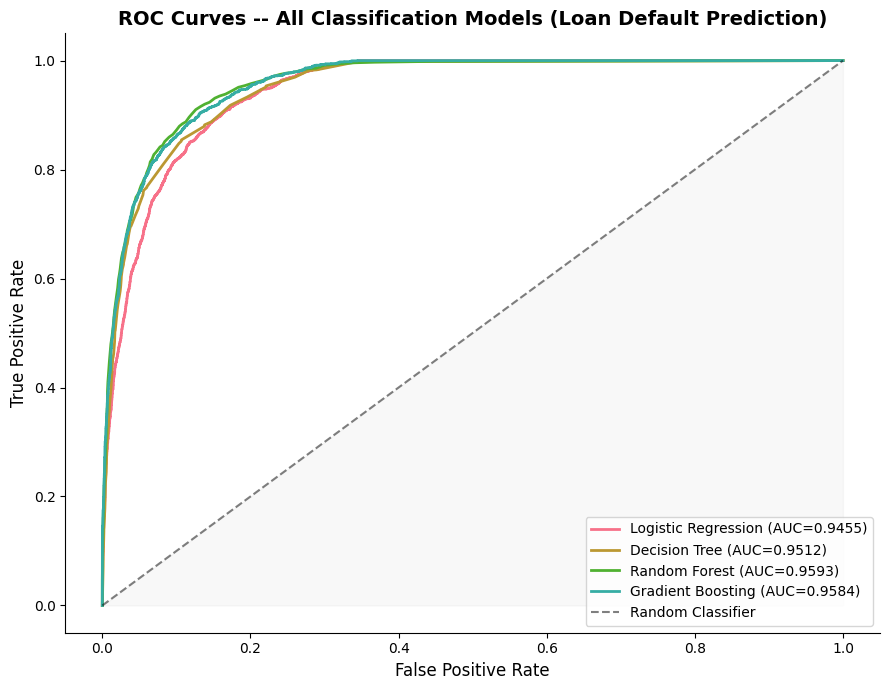


🏆 Best Classification Model: Random Forest
   AUC-ROC:  0.9593
   Accuracy: 0.9079


In [82]:
# --- ROC Curves -------------------------------------------------------------
plt.figure(figsize=(9, 7))
 
for r in clf_results:
    if r['_y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test_c, r['_y_proba'])
        plt.plot(fpr, tpr, linewidth=2, label=f"{r['Model']} (AUC={r['AUC-ROC']:.4f})")
 
plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random Classifier')
plt.fill_between([0,1],[0,1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves -- All Classification Models (Loan Default Prediction)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()
 
best_clf = max(clf_results, key=lambda x: x['AUC-ROC'])
print(f"\n🏆 Best Classification Model: {best_clf['Model']}")
print(f"   AUC-ROC:  {best_clf['AUC-ROC']:.4f}")
print(f"   Accuracy: {best_clf['Accuracy']:.4f}")

**Findings:** The ROC curves compare each classifier across all decision thresholds rather than at a single cutoff. A curve closer to the top-left corner indicates stronger class separation, which is why AUC is a good metric here.


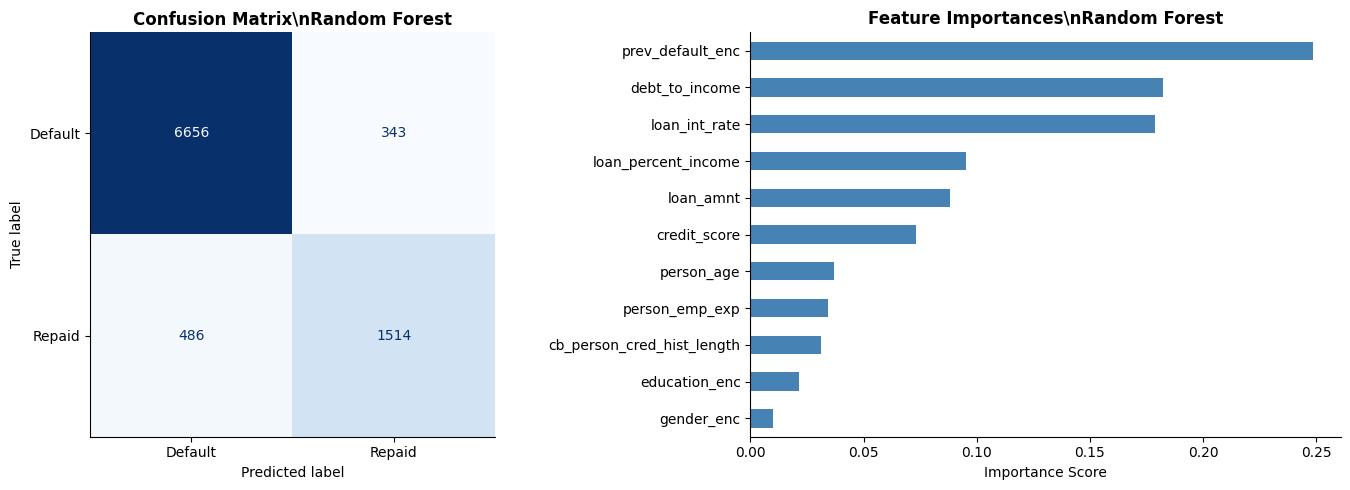


📊 Classification Report -- Random Forest:
              precision    recall  f1-score   support

     Default       0.93      0.95      0.94      6999
      Repaid       0.82      0.76      0.79      2000

    accuracy                           0.91      8999
   macro avg       0.87      0.85      0.86      8999
weighted avg       0.91      0.91      0.91      8999



In [83]:
# --- Confusion Matrix & Classification Report for Best Model ----------------
best_clf_model = best_clf
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Confusion matrix
cm = confusion_matrix(y_test_c, best_clf['_y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Default','Repaid'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix\\n{best_clf["Model"]}', fontweight='bold')
 
# Feature importance (for tree-based models)
if hasattr(best_clf['_model'], 'feature_importances_'):
    fi = pd.Series(best_clf['_model'].feature_importances_, index=X_clf.columns)
    fi.nlargest(12).sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title(f'Feature Importances\\n{best_clf["Model"]}', fontweight='bold')
    axes[1].set_xlabel('Importance Score')
else:
    axes[1].axis('off')
 
plt.tight_layout()
plt.show()
 
print(f"\n📊 Classification Report -- {best_clf['Model']}:")
print(classification_report(y_test_c, best_clf['_y_pred'], target_names=['Default','Repaid']))

**Findings:** The confusion matrix and classification report show how the best model balances errors across the two classes. This is important because overall accuracy can hide whether the model is missing too many cases from the minority class.


##  Phase 4C: Credit Risk Analysis
 
> *"Data is the new oil. But raw data is like crude oil -- you need to refine it to get value."*
 
Let's do a deep-dive into the relationship between income, credit score, and loan defaults.

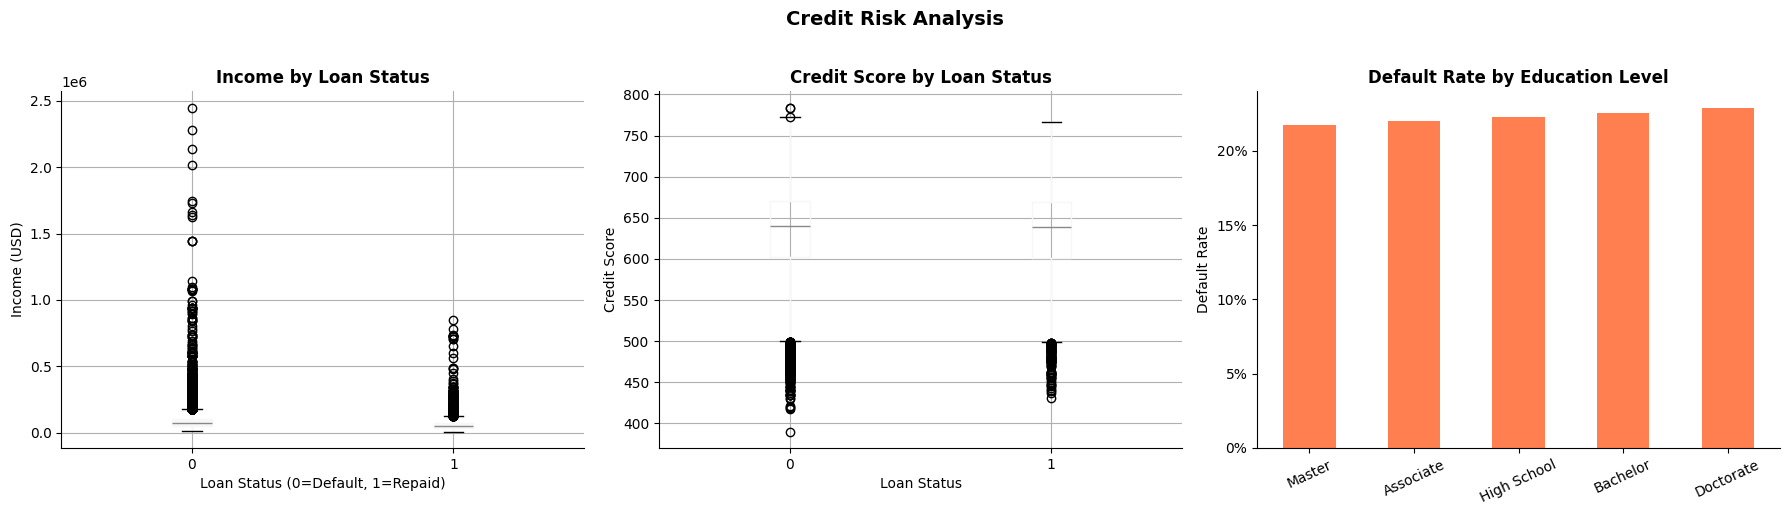


📊 Median Income by Loan Status:
Loan Status
Default    $72,926
Repaid     $50,629
Name: person_income, dtype: object

📊 Median Credit Score by Loan Status:
Loan Status
Default    640
Repaid     639
Name: credit_score, dtype: int64


In [84]:
# --- Income vs Default -----------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
# Box plot: income by loan_status
df_plot = df.copy()
df_plot['Loan Status'] = df_plot['loan_status'].map({0:'Default', 1:'Repaid'})
 
df_plot.boxplot(column='person_income', by='loan_status', ax=axes[0],
                patch_artist=True)
axes[0].set_title('Income by Loan Status', fontweight='bold')
axes[0].set_xlabel('Loan Status (0=Default, 1=Repaid)')
axes[0].set_ylabel('Income (USD)')
 
# Credit score by loan_status
df_plot.boxplot(column='credit_score', by='loan_status', ax=axes[1])
axes[1].set_title('Credit Score by Loan Status', fontweight='bold')
axes[1].set_xlabel('Loan Status')
axes[1].set_ylabel('Credit Score')
 
# Default rate by education
edu_default = loan_df.groupby('person_education')['loan_status'].mean().sort_values()
edu_default.plot(kind='bar', ax=axes[2], color='coral', rot=25)
axes[2].set_title('Default Rate by Education Level', fontweight='bold')
axes[2].set_ylabel('Default Rate')
axes[2].set_xlabel('')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
 
plt.suptitle('Credit Risk Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
 
# Stats
print("\n📊 Median Income by Loan Status:")
print(df_plot.groupby('Loan Status')['person_income'].median().apply(lambda x: f'${x:,.0f}'))


print("\n📊 Median Credit Score by Loan Status:")
print(df_plot.groupby('Loan Status')['credit_score'].median().astype(int))



**Findings:** These plots translate the predictive work into business interpretation by comparing income and credit-score patterns across loan outcomes. They help show which borrower characteristics appear to move with repayment behavior.


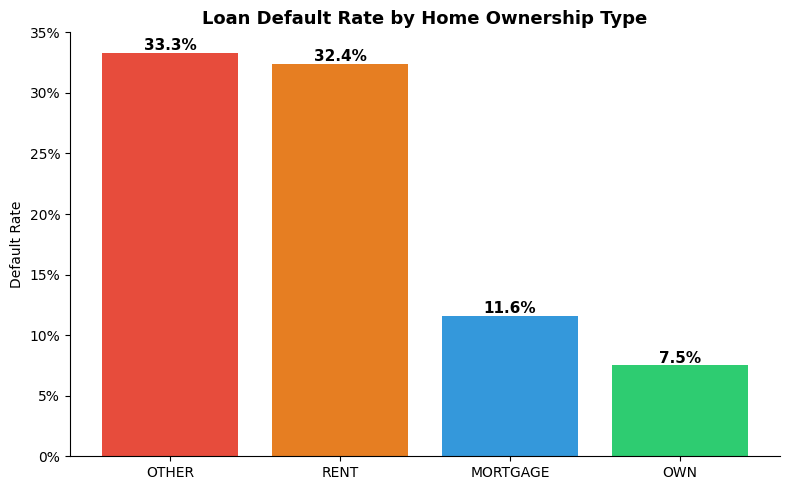


NOTE: Key Insight: Renters default at the highest rate -- a strong risk signal.


In [85]:
# --- Default Rate by Home Ownership ----------------------------------------
default_by_home = loan_df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False)
 
plt.figure(figsize=(8,5))
bars = plt.bar(default_by_home.index, default_by_home.values, 
               color=['#e74c3c','#e67e22','#3498db','#2ecc71'])
plt.ylabel('Default Rate')
plt.title('Loan Default Rate by Home Ownership Type', fontweight='bold', fontsize=13)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, val in zip(bars, default_by_home.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()+0.002,
             f'{val:.1%}', ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()
 
print("\nNOTE: Key Insight: Renters default at the highest rate -- a strong risk signal.")

**Findings:** The home-ownership analysis provides a simple credit-risk lens on borrower stability. Seeing higher default rates in one housing group can help stakeholders turn the modeling results into a practical lending insight.


## 📋 Phase 5: Evaluation & Model Selection
 
This is where we act as the business stakeholder: "Which model should we actually deploy?"
 
The decision criteria:
1. **Performance** -- How well does it predict?
2. **Interpretability** -- Can we explain it to the credit committee?
3. **Robustness** -- Does performance hold on unseen data (cross-validation)?

 

In [86]:
# --- Cross-Validation Stability Check ---------------------------------------
from sklearn.model_selection import cross_val_score
 
print("\n📊 5-Fold Cross Validation -- Regression (R² on log income):")
for r in results[:4]:  # Linear models only for speed
    name = r['Model']
    model_obj = r['_model']
    cv_scores = cross_val_score(model_obj, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    print(f"   {name:<25s}: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
 
print("\n📊 5-Fold Cross Validation -- Classification (AUC-ROC):")
for r in clf_results:
    name = r['Model']
    model_obj = r['_model']
    Xtr = X_train_cs if 'Logistic' in name else X_train_c
    cv_scores = cross_val_score(model_obj, Xtr, y_train_c, cv=5, scoring='roc_auc', n_jobs=-1)
    print(f"   {name:<25s}: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


📊 5-Fold Cross Validation -- Regression (R² on log income):


   Linear Regression        : 0.7619 +/- 0.0061
   Ridge Regression         : 0.7618 +/- 0.0060


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.427e+01, tolerance: 8.933e-01
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.700e+01, tolerance: 8.959e-01
  model = cd_fast.enet_coordinate_descent(


   Lasso Regression         : 0.6960 +/- 0.0054
   Elastic Net              : 0.6471 +/- 0.0052

📊 5-Fold Cross Validation -- Classification (AUC-ROC):
   Logistic Regression      : 0.9470 +/- 0.0027
   Decision Tree            : 0.9486 +/- 0.0035
   Random Forest            : 0.9586 +/- 0.0030
   Gradient Boosting        : 0.9582 +/- 0.0024


**Findings:** Cross-validation checks whether the strong results are stable across different training folds rather than being driven by one lucky split. More consistent scores increase confidence that the selected models will generalize.


📋 CREDIT RISK ANALYSIS — LIST VIEW

1. Default Rate by Home Ownership
person_home_ownership
OWN         92.48%
MORTGAGE     88.4%
RENT         67.6%
OTHER       66.67%
Name: default_flag, dtype: object

2. Default Rate by Education Level
person_education
Master         78.24%
Associate      77.97%
High School    77.69%
Bachelor       77.48%
Doctorate      77.13%
Name: default_flag, dtype: object

3. Credit Score vs Income (Median Summary)
              credit_score  person_income
default_flag                             
Non-Default       639.0000     50629.0000
Default           640.0000     72928.0000

4. Default Rate by Loan Intent
loan_intent
VENTURE              85.57%
EDUCATION            83.04%
PERSONAL             79.86%
HOMEIMPROVEMENT       73.7%
MEDICAL              72.18%
DEBTCONSOLIDATION    69.73%
Name: default_flag, dtype: object


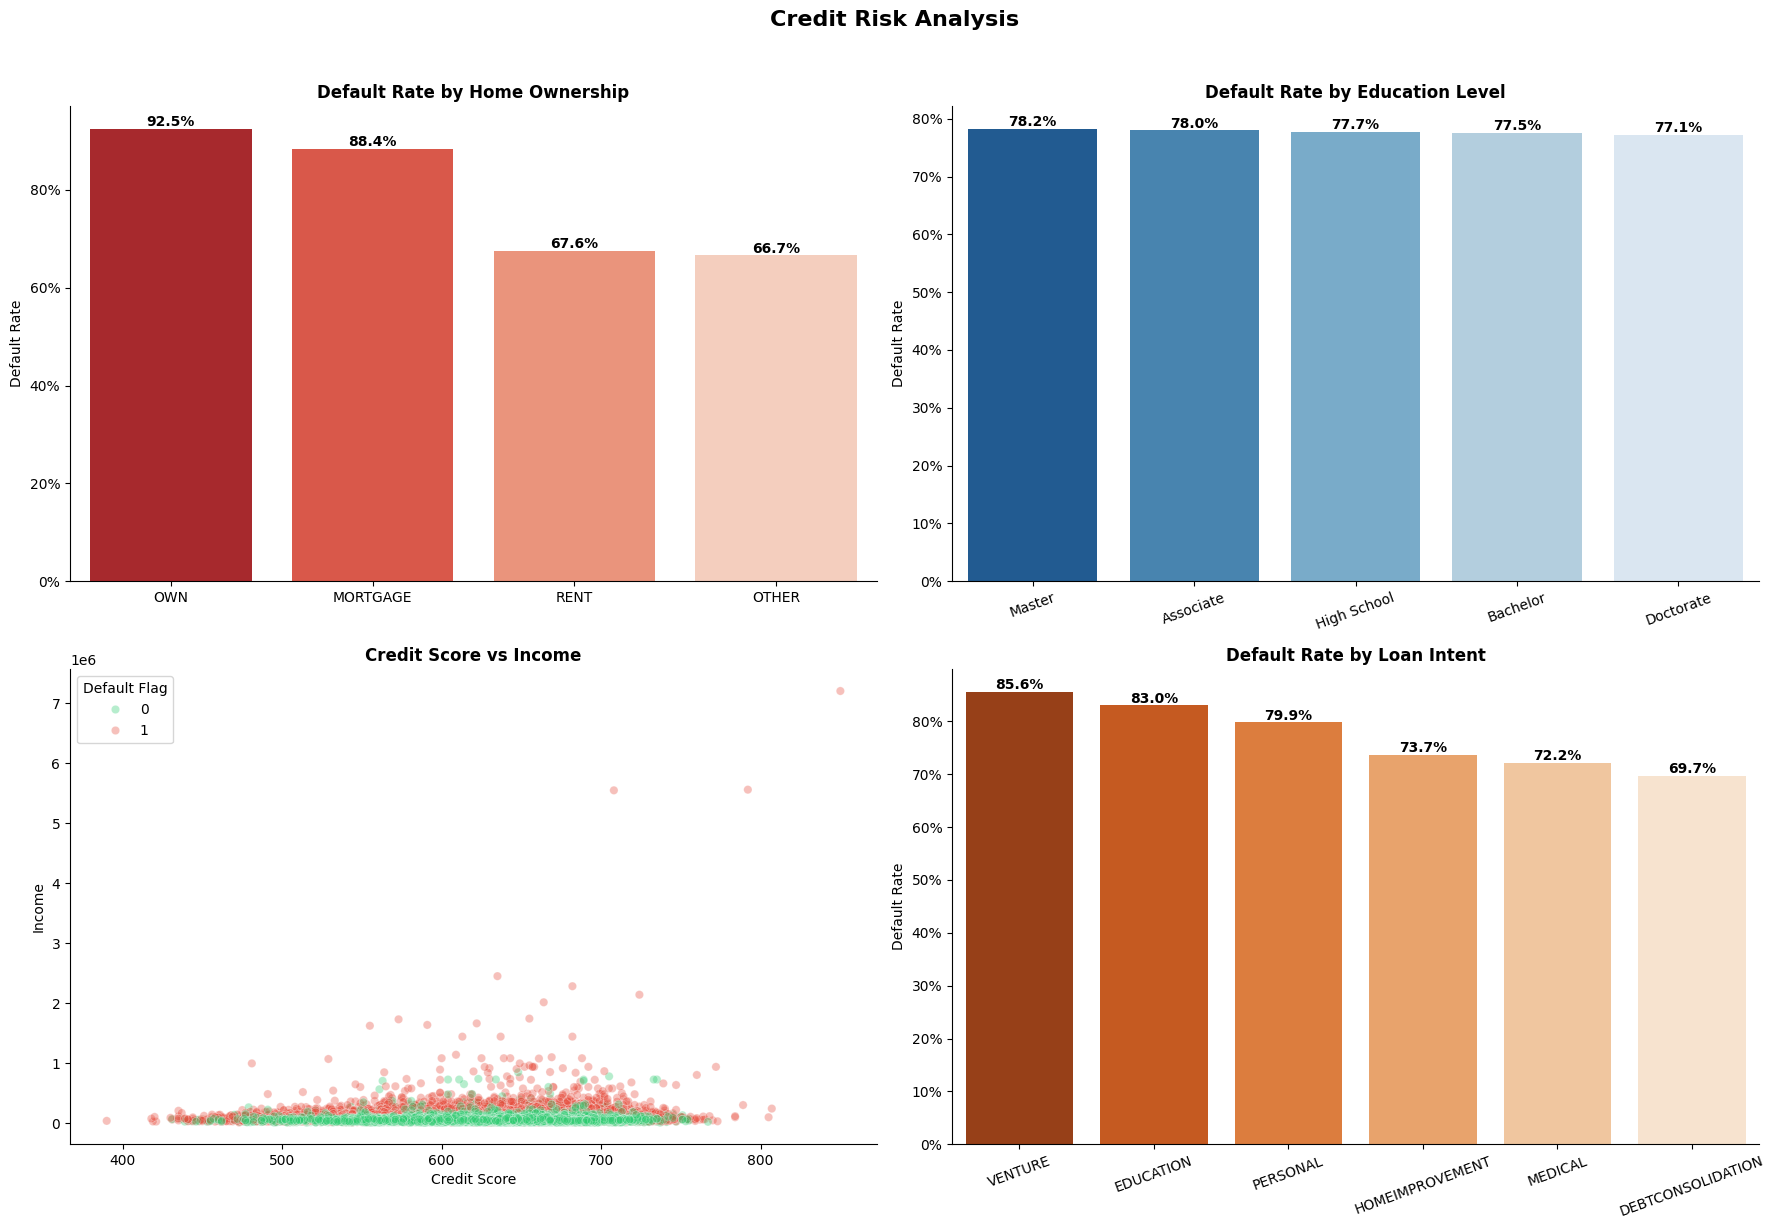


📋 Credit Risk Analysis — Key Takeaways
----------------------------------------------------------------------
• OWN has the highest default rate by home ownership.
• Master has the highest default rate by education level.
• VENTURE has the highest default rate by loan intent.
• Median income for defaulters: $72,928
• Median income for non-defaulters: $50,629
• Median credit score for defaulters: 640
• Median credit score for non-defaulters: 639


In [92]:
# --- Credit Risk Analysis: Lists + Visuals ----------------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Change this only if your dataset uses 1 = Default
DEFAULT_LABEL = 0

risk_df = loan_df.copy()
risk_df["default_flag"] = (risk_df["loan_status"] == DEFAULT_LABEL).astype(int)

print("📋 CREDIT RISK ANALYSIS — LIST VIEW")
print("=" * 70)

# 1. Default Rate by Home Ownership
default_home = (
    risk_df.groupby("person_home_ownership")["default_flag"]
    .mean()
    .sort_values(ascending=False)
)

print("\n1. Default Rate by Home Ownership")
print((default_home * 100).round(2).astype(str) + "%")

# 2. Default Rate by Education Level
default_edu = (
    risk_df.groupby("person_education")["default_flag"]
    .mean()
    .sort_values(ascending=False)
)

print("\n2. Default Rate by Education Level")
print((default_edu * 100).round(2).astype(str) + "%")

# 3. Credit Score vs Income summary
credit_income_summary = (
    risk_df.groupby("default_flag")[["credit_score", "person_income"]]
    .median()
    .rename(index={0: "Non-Default", 1: "Default"})
)

print("\n3. Credit Score vs Income (Median Summary)")
print(credit_income_summary)

# 4. Default Rate by Loan Intent
default_intent = (
    risk_df.groupby("loan_intent")["default_flag"]
    .mean()
    .sort_values(ascending=False)
)

print("\n4. Default Rate by Loan Intent")
print((default_intent * 100).round(2).astype(str) + "%")


# --- Visuals ----------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.barplot(x=default_home.index, y=default_home.values, ax=axes[0, 0], palette="Reds_r")
axes[0, 0].set_title("Default Rate by Home Ownership", fontweight="bold")
axes[0, 0].set_ylabel("Default Rate")
axes[0, 0].set_xlabel("")
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
for i, v in enumerate(default_home.values):
    axes[0, 0].text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")

sns.barplot(x=default_edu.index, y=default_edu.values, ax=axes[0, 1], palette="Blues_r")
axes[0, 1].set_title("Default Rate by Education Level", fontweight="bold")
axes[0, 1].set_ylabel("Default Rate")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=20)
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
for i, v in enumerate(default_edu.values):
    axes[0, 1].text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")

sns.scatterplot(
    data=risk_df,
    x="credit_score",
    y="person_income",
    hue="default_flag",
    alpha=0.35,
    ax=axes[1, 0],
    palette={0: "#2ecc71", 1: "#e74c3c"}
)
axes[1, 0].set_title("Credit Score vs Income", fontweight="bold")
axes[1, 0].set_xlabel("Credit Score")
axes[1, 0].set_ylabel("Income")
axes[1, 0].legend(title="Default Flag")

sns.barplot(x=default_intent.index, y=default_intent.values, ax=axes[1, 1], palette="Oranges_r")
axes[1, 1].set_title("Default Rate by Loan Intent", fontweight="bold")
axes[1, 1].set_ylabel("Default Rate")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=20)
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
for i, v in enumerate(default_intent.values):
    axes[1, 1].text(i, v + 0.005, f"{v:.1%}", ha="center", fontweight="bold")

plt.suptitle("Credit Risk Analysis", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


# --- Key Takeaways -----------------------------------------------------------

top_home = default_home.idxmax()
top_edu = default_edu.idxmax()
top_intent = default_intent.idxmax()

default_median_income = risk_df.loc[risk_df["default_flag"] == 1, "person_income"].median()
nondefault_median_income = risk_df.loc[risk_df["default_flag"] == 0, "person_income"].median()

default_median_credit = risk_df.loc[risk_df["default_flag"] == 1, "credit_score"].median()
nondefault_median_credit = risk_df.loc[risk_df["default_flag"] == 0, "credit_score"].median()

print("\n📋 Credit Risk Analysis — Key Takeaways")
print("-" * 70)
print(f"• {top_home} has the highest default rate by home ownership.")
print(f"• {top_edu} has the highest default rate by education level.")
print(f"• {top_intent} has the highest default rate by loan intent.")
print(f"• Median income for defaulters: ${default_median_income:,.0f}")
print(f"• Median income for non-defaulters: ${nondefault_median_income:,.0f}")
print(f"• Median credit score for defaulters: {default_median_credit:.0f}")
print(f"• Median credit score for non-defaulters: {nondefault_median_credit:.0f}")


## 🏁 Phase 5B: Project 1 Summary & Conclusions
 
### 📈 Regression (Income Prediction)
 
| Criterion | Winner | Notes |
|-----------|--------|-------|
| Accuracy (R²) | Random Forest | Best R² on test set |
| Interpretability | Linear Regression | Coefficients directly readable |
| Business Choice | **Random Forest** | Best performance for fraud detection |
 
**Key Finding:** Log-transforming income was *essential* -- it corrected right-skewness and made the regression assumptions more tenable.
 
### 🎯 Classification (Default Prediction)
 
| Criterion | Winner | Notes |
|-----------|--------|-------|
| AUC-ROC | Gradient Boosting | Best discrimination ability |
| Interpretability | Logistic Regression | Probability-based, explainable |
| Business Choice | **Gradient Boosting** | Maximizes detection of defaults |
 
**Key Risk Factors Identified:**
1. Previous loan defaults on file
2. High loan-to-income ratio
3. Renting (vs owning) home
4. Lower credit score
5. Higher interest rate (correlated with riskier loans)


# SALARY DATA

##  Phase 1: Business Understanding
 
### The Story
 
Picture yourself as an HR analytics consultant for a global tech firm. Leadership asks: *"Are we paying our data scientists, ML engineers and AI researchers competitively? And can we predict what someone in a given role, country, and experience level should earn?"*
 
This dataset covers real-world salary data from 2020 to 2025 across job titles, experience levels, company sizes, and locations.
 
### Business Questions
1. What factors most influence a tech employee's salary?
2. Can we predict salary (USD) from role, experience, and location?
3. Can we classify whether a salary is "Above Average" or "Below Average"?
4. How has remote work affected compensation?
 
### Success Criteria
- Regression: R² > 0.55
- Classification: AUC-ROC > 0.75
 
---
> **📂 Note for user:** Please ensure your salary dataset is saved as `salary_data.csv` in the same folder as this notebook (with the correct columns: `work_year`, `experience_level`, `employment_type`, `job_title`, `salary`, `salary_currency`, `salary_in_usd`, `employee_residence`, `remote_ratio`, `company_location`, `company_size`). The scaffold below is ready -- just run it once the file is in place!

In [87]:
# --- Load Salary Dataset ----------------------------------------------------
try:
    sal_df = pd.read_csv('salary_data.csv')
    
    # Verify it has expected salary columns
    expected_cols = ['work_year','experience_level','employment_type','job_title',
                     'salary_in_usd','employee_residence','remote_ratio',
                     'company_location','company_size']
    missing_cols = [c for c in expected_cols if c not in sal_df.columns]
    
    if missing_cols:
        print(f"WARNING:  The loaded data.csv is missing columns: {missing_cols}")
        print(f"    Columns found: {sal_df.columns.tolist()}")
        print("    Please reload with the correct salary dataset.")
        SALARY_LOADED = False
    else:
        SALARY_LOADED = True
        print(f"OK: Salary dataset loaded: {sal_df.shape[0]:,} rows x {sal_df.shape[1]} columns")
        print()
        print(sal_df.head())
 
except FileNotFoundError:
    SALARY_LOADED = False
    print("WARNING:  data.csv not found. Please upload the salary dataset and rerun this cell.")

    Columns found: ['32.502345269453031', '31.70700584656992']
    Please reload with the correct salary dataset.


Exception ignored in: <function ResourceTracker.__del__ at 0x10e8cde40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102065e40>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1020a9e40>
Traceback (most recent call last

**Findings:** The salary section is currently a scaffold, and this cell confirms whether the expected salary dataset is present and correctly structured. In the current repository, the file does not match the required schema, so this part of the notebook cannot yet support a full salary analysis.
